# Wilcoxon signed-rank test (paired samples)

Passive: N paired = 20
Active: N paired = 20


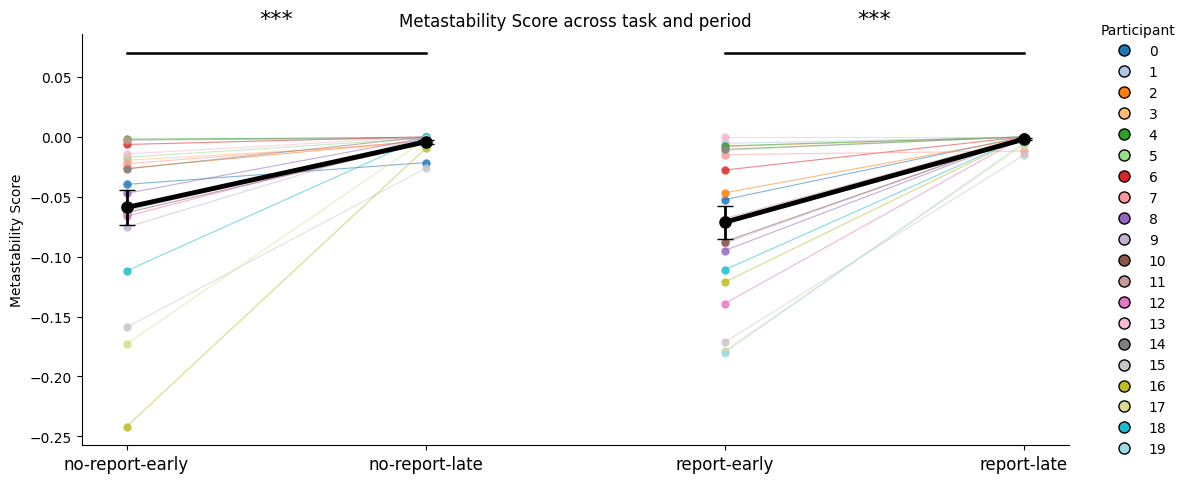

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import wilcoxon
from matplotlib.lines import Line2D

import os
repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

# =======================
# Configuration
# =======================

conditions = [
    ("Passive", "early"),
    ("Passive", "late"),
    ("Active", "early"),
    ("Active", "late"),
]

condition_order = [
    "Passive-early",
    "Passive-late",
    "Active-early",
    "Active-late",
]

# =======================
# Load data
# =======================
dfs = []

for task, period in conditions:
    base_path = Path(f"Fit_{task}_{period}")
    csv_path = base_path / "metastability_scores.csv"
    df = pd.read_csv(csv_path, index_col=0)
    
    df["SubID"] = df.index
    df["task"] = task
    df["period"] = period
    df["condition"] = f"{task}-{period}"
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# =======================
# Plot label mapping (for plotting only)
# =======================
map_task = {"Passive": "no-report", "Active": "report"}
data["task_plot"] = data["task"].map(map_task)
data["condition_plot"] = data["task_plot"] + '-' + data["period"]

condition_order_plot = [
    "no-report-early",
    "no-report-late",
    "report-early",
    "report-late",
]

# =======================
# Styling
# =======================
# sns.set_theme(style="whitegrid", context="talk")

subids = sorted(data["SubID"].unique())
palette = sns.color_palette("tab20", len(subids))
subid_color = dict(zip(subids, palette))

# =======================
# Plot
# =======================
fig, ax = plt.subplots(figsize=(12, 5))

# ---- Pairing lines (early → late within task)
for task in ["Passive", "Active"]:
    early = data[(data.task == task) & (data.period == "early")]
    late  = data[(data.task == task) & (data.period == "late")]

    for sub in set(early.SubID).intersection(late.SubID):
        y1 = early.loc[early.SubID == sub, "metastability_score"].values[0]
        y2 = late.loc[late.SubID == sub, "metastability_score"].values[0]
        x1 = condition_order_plot.index(f"{map_task[task]}-early")
        x2 = condition_order_plot.index(f"{map_task[task]}-late")

        ax.plot(
            [x1, x2], [y1, y2],
            color=subid_color[sub], alpha=0.55, linewidth=0.8, zorder=1
        )

# ---- Rain (points only), colored by subject
for sub, df_sub in data.groupby("SubID"):
    sns.stripplot(
        data=df_sub,
        x="condition_plot",
        y="metastability_score",
        order=condition_order_plot,
        jitter=0.18,
        size=6,
        alpha=0.85,
        color=subid_color[sub],
        ax=ax,
        zorder=2
    )

# ---- Mean ± SEM
stats = (
    data.groupby("condition_plot")["metastability_score"]
    .agg(["mean", "sem"])
    .reindex(condition_order_plot)
)

x = np.arange(len(condition_order_plot))

# Bold black mean connector lines within each task
ax.plot([0, 1], [stats.loc["no-report-early", "mean"], stats.loc["no-report-late", "mean"]],
        color="black", linewidth=3.5, zorder=2.6)
ax.plot([2, 3], [stats.loc["report-early", "mean"], stats.loc["report-late", "mean"]],
        color="black", linewidth=3.5, zorder=2.6)

ax.errorbar(
    x=x,
    y=stats["mean"],
    yerr=stats["sem"],
    fmt="o",
    color="black",
    capsize=6,
    markersize=8,
    linewidth=2,
    zorder=3
)

# =======================
# Statistics
# =======================
def paired_p(task):

    e = data[(data.task == task) & (data.period == "early")]
    l = data[(data.task == task) & (data.period == "late")]

    # Set SubID as index for alignment
    e = e.set_index("SubID")
    l = l.set_index("SubID")

    # Keep only subjects present in BOTH
    common = e.index.intersection(l.index)

    # Align explicitly
    e_vals = e.loc[common, "metastability_score"]
    l_vals = l.loc[common, "metastability_score"]

    # Remove any NaNs just in case
    valid = ~(e_vals.isna() | l_vals.isna())
    e_vals = e_vals[valid]
    l_vals = l_vals[valid]

    print(f"{task}: N paired = {len(e_vals)}")

    if len(e_vals) < 2:
        print(f"{task}: Not enough paired data.")
        return np.nan

    _, p = wilcoxon(e_vals, l_vals)
    return p

def stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "p=" + str(p)[:5]

p_passive = paired_p("Passive")
p_active  = paired_p("Active")

# ---- Annotations (ONLY if significant)
def annotate(x1, x2, y, text):
    ax.plot([x1, x2], [y, y], color="black", linewidth=1.8)
    ax.text((x1 + x2) / 2, y + 0.02, text,
            ha="center", va="bottom", fontsize=16)

y_top = data["metastability_score"].max() + 0.07

if stars(p_passive):
    annotate(0, 1, y_top, stars(p_passive))

if stars(p_active):
    annotate(2, 3, y_top, stars(p_active))

# =======================
# Participant color legend
# =======================
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label=str(sub),
        markerfacecolor=subid_color[sub],
        markersize=8
    )
    for sub in subids
]

ax.legend(
    handles=legend_elements,
    title="Participant",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=False
)

# =======================
# Final touches
# =======================
ax.set_ylabel("Metastability Score")
ax.set_xlabel("")
# ax.set_ylim(0, 1.15)
ax.set_title("Metastability Score across task and period")
ax.tick_params(axis="x", labelsize=12)

sns.despine()
plt.tight_layout()
plt.savefig('MetastabilityScoreAcrossConditions.png')
plt.show()



In [5]:
# Compare Active vs Passive in late condition (unpaired)
from scipy.stats import mannwhitneyu

late_data = data[data.period == "late"]
active_late = late_data[late_data.task == "Active"]["metastability_score"]
passive_late = late_data[late_data.task == "Passive"]["metastability_score"]

print(f"Active (late):  mean = {active_late.mean():.5f}, N = {len(active_late)}")
print(f"Passive (late): mean = {passive_late.mean():.5f}, N = {len(passive_late)}")

u_stat, p_val = mannwhitneyu(active_late, passive_late)
print(f"Mann-Whitney U test: p = {p_val:.4f}")

Active (late):  mean = -0.00204, N = 20
Passive (late): mean = -0.00421, N = 20
Mann-Whitney U test: p = 0.1017


In [8]:
# Compare Active vs Passive in late condition (unpaired)
from scipy.stats import mannwhitneyu

early_data = data[data.period == "early"]
active_early = early_data[early_data.task == "Active"]["metastability_score"]
passive_early = early_data[early_data.task == "Passive"]["metastability_score"]

print(f"Active (early):  mean = {active_early.mean():.5f}, N = {len(active_early)}")
print(f"Passive (early): mean = {passive_early.mean():.5f}, N = {len(passive_early)}")

u_stat, p_val = mannwhitneyu(active_early, passive_early)
print(f"Mann-Whitney U test: p = {p_val:.4f}")

Active (early):  mean = -0.07132, N = 20
Passive (early): mean = -0.05900, N = 20
Mann-Whitney U test: p = 0.4903
